# Grilla de ejemplos: números (0-9, sin el "0")

Toma UNA imagen de ejemplo por cada carpeta numérica en `data/asl_dataset/`
(excepto "0", que se excluyó del dataset), corre MediaPipe sobre cada una,
y las muestra en una grilla CON los landmarks dibujados encima de la mano.


In [1]:
import math
from pathlib import Path

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

DATASET_DIR = Path("../data/asl_dataset")
MIN_DETECTION_CONFIDENCE = 0.5


In [2]:
def one_example_per_class(dataset_dir: Path, class_filter):
    examples = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        if not class_filter(class_dir.name):
            continue

        images = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        if images:
            examples[class_dir.name] = images[0]

    return examples


def draw_landmarks_on_image(image_path: Path, hands):
    """Lee una imagen, corre MediaPipe, devuelve (imagen_anotada_RGB, n_manos_detectadas)."""
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    results = hands.process(image_rgb)
    n_hands = len(results.multi_hand_landmarks) if results.multi_hand_landmarks else 0

    annotated = image_rgb.copy()
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                annotated, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                mp_styles.get_default_hand_landmarks_style(),
                mp_styles.get_default_hand_connections_style(),
            )

    return annotated, n_hands


def plot_grid(examples: dict, title: str, cols: int = 5):
    labels = sorted(examples.keys(), key=int)
    n = len(labels)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
    axes = axes.flatten() if n > 1 else [axes]

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=MIN_DETECTION_CONFIDENCE,
    ) as hands:
        for ax, label in zip(axes, labels):
            annotated, n_hands = draw_landmarks_on_image(examples[label], hands)

            ax.imshow(annotated)
            title_color = "red" if n_hands == 0 else "black"
            ax.set_title(f"{label} ({n_hands}m)", fontsize=14, fontweight="bold", color=title_color)
            ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


Números encontrados: ['1', '2', '3', '4', '5', '6', '7', '8', '9']


c:\Users\conso\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


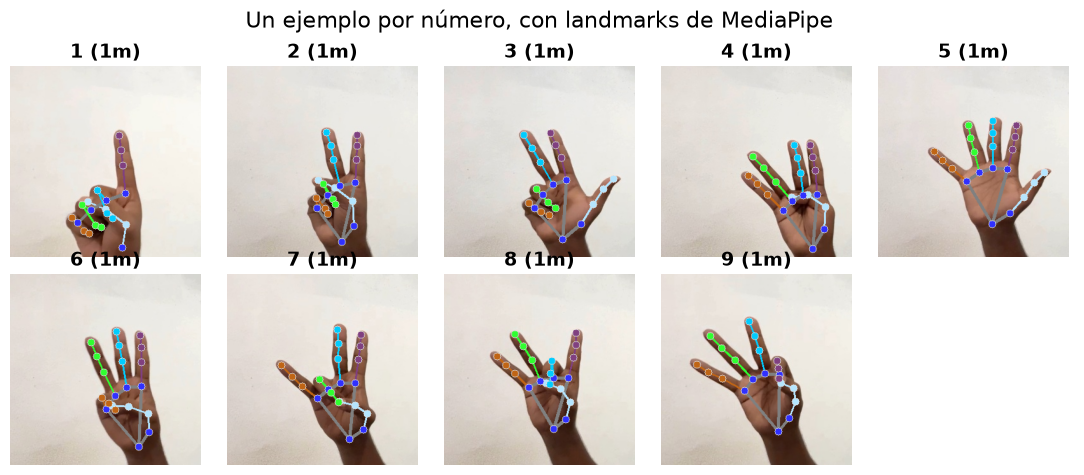

In [3]:
number_examples = one_example_per_class(DATASET_DIR, class_filter=lambda name: name.isdigit())

print(f"Números encontrados: {sorted(number_examples.keys(), key=int)}")

plot_grid(number_examples, title="Un ejemplo por número, con landmarks de MediaPipe")
